# This notebook describes work done in support of PR #369.

# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
we can inspect each intermediate step in isolation — before moving to the next cell. This helps us understand how the method works, how different steps in the process impact the results, and diagnose and resolve any issues.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `srm.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [1]:
%load_ext autoreload
%autoreload 2

import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.downscaling_utils import (
    calculate_doy_means,
    downscale_from_coarse,
    get_historical_experiment,
    get_obs,
    interpolate_coarse_to_fine_grid,
    interpolate_fine_to_coarse_grid,
    retrend,
    subset_space
)
from srm.pipeline import BCSDPipeline
from srm.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from srm.validation import CheckStatus

warnings.filterwarnings("ignore", category=FutureWarning)


def _step_title(step: str, width: int = 16) -> str:
    """Wrap a snake_case step name to fit in a narrow subplot title."""
    return textwrap.fill(step.replace("_", " "), width=width)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [2]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "dtr"
ENSEMBLE_MEMBER = "001"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = "None"

# Southern Africa including high spot in Angola.
# (lat_min, lat_max, lon_min, lon_max)
SUBSET_BOUNDS = (-35.0, -16.0, 15.0, 39.0)
# ──────────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2060 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")

Run: CESM2-WACCM_dtr_001_NONE_subset
Subset bounds: (-35.0, -16.0, 15.0, 39.0)
Scenario: 'NONE'
Predict period: 2015–2060


## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [3]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## ERA5-relative exceedance helpers

Adapted from `synced/notebooks/check_reasonable_ranges.ipynb`. Unlike the
global physical-bounds check in `qa_checks.py`, these compare the downscaled
output against ERA5's **per-pixel** historical min/max — so a value that is
physically plausible globally but implausible at that specific location is
still flagged.

`obs_fine_s2` / `obs_fine_s3` (already in memory) serve as the ERA5
reference, so no extra S3 reads are needed.


In [4]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero exceedances; continuous Reds for nonzero — makes clean regions
# immediately obvious without needing a separate mask plot.
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def _era5_threshold(obs_fine: xr.DataArray, direction: str, period: str) -> xr.DataArray:
    """Per-pixel ERA5 min/max from obs_fine already in memory.

    Parameters
    ----------
    obs_fine : already-computed fine-grid ERA5 DataArray
    direction : "gt" → max threshold; "lt" → min threshold
    period    : "annual" or "monthly"
    """
    fn = "max" if direction == "gt" else "min"
    if period == "annual":
        return getattr(obs_fine, fn)("time").compute()
    return getattr(obs_fine.groupby("time.month"), fn)("time").compute()


def _count_exceedances(
    da: xr.DataArray,
    threshold: xr.DataArray,
    direction: str,
    period: str,
) -> xr.DataArray:
    """Number of time steps per pixel that exceed the given threshold."""
    if period == "annual":
        mask = da > threshold if direction == "gt" else da < threshold
        return mask.sum("time").compute()
    counts = []
    for m, group in da.groupby("time.month"):
        exceeded = (
            group > threshold.sel(month=m) if direction == "gt" else group < threshold.sel(month=m)
        )
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").compute()


def _plot_map(da, ax, title, **kw):
    """Single-panel map with optional cartopy coastlines."""
    proj_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    da.plot(ax=ax, **kw, **proj_kw)
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=9)


def plot_time_extremes(da: xr.DataArray, label: str) -> None:
    """2×2 grid: time-min and time-max with default and robust color scaling."""
    proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), subplot_kw=proj)
    fig.suptitle(f"{label} — time extremes", fontweight="bold")
    _plot_map(da.min("time"), axes[0, 0], "time min")
    _plot_map(da.max("time"), axes[0, 1], "time max")
    _plot_map(da.min("time"), axes[1, 0], "time min (robust)", robust=True)
    _plot_map(da.max("time"), axes[1, 1], "time max (robust)", robust=True)
    plt.tight_layout()
    plt.show()


def check_era5_exceedances(
    da: xr.DataArray,
    obs_fine: xr.DataArray,
    label: str,
    period: str = "annual",
) -> None:
    """Flag pixels where da ever exceeds ERA5's per-pixel historical min/max.

    Prints pixel counts and plots exceedance maps (grey = clean, Reds = flagged).
    Set period="monthly" for a 3×4 faceted map — slower but more granular.
    """
    print(f"\n── ERA5-relative exceedance: {label} ({period}) ──")
    n_pixels = int(da.isel(time=0).size)

    for direction, label_suffix in [("gt", "days > ERA5 max"), ("lt", "days < ERA5 min")]:
        thresh = _era5_threshold(obs_fine, direction, period)
        count = _count_exceedances(da, thresh, direction, period)

        n_flagged = int((count > 0).sum().values)
        pct = n_flagged / n_pixels
        sym = "✗" if n_flagged > 0 else "✓"
        print(f"  {sym} {label_suffix}: {n_flagged}/{n_pixels} pixels flagged ({pct:.1%})")

        proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
        if period == "annual":
            fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=proj)
            _plot_map(count, ax, f"{label}\n{label_suffix}", cmap=_EXCEEDANCE_CMAP, vmin=0.5)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(3, 4, figsize=(20, 10), subplot_kw=proj)
            fig.suptitle(f"{label}\n{label_suffix}", fontsize=11)
            for i, ax in enumerate(axes.flat):
                _plot_map(
                    count.sel(month=i + 1),
                    ax,
                    _MONTH_NAMES[i],
                    cmap=_EXCEEDANCE_CMAP,
                    vmin=0.5,
                )
            plt.tight_layout()
            plt.show()

## Stage 1 — `prepare_observations`

Replicates the internals of `BCSDPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.



  obs_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 77, 'lon': 97}
  NaN:   0.0000 (0.00%)


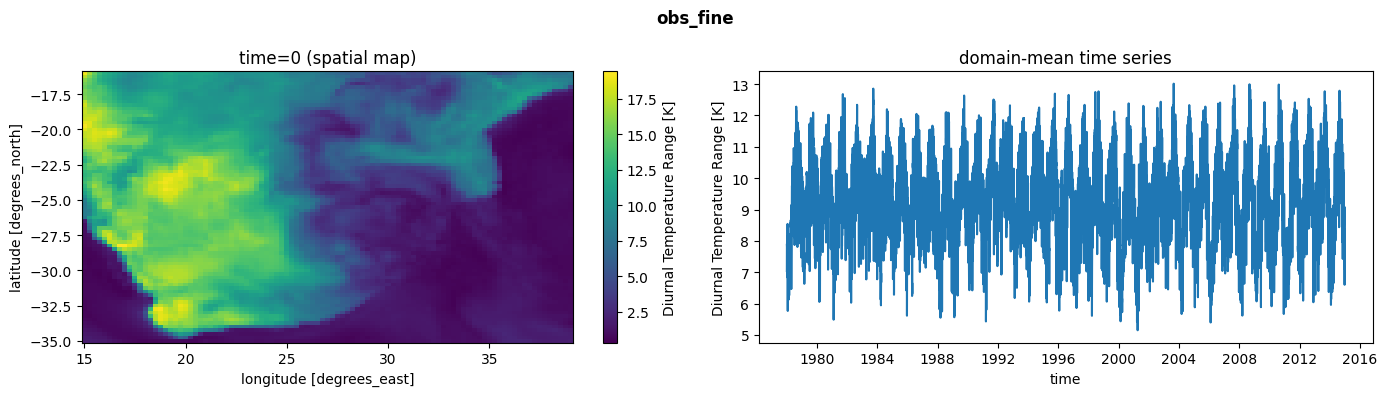

In [5]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice)
obs_fine = inspect(obs_fine, "obs_fine")


  model_grid
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 20, 'lon': 20}
  NaN:   0.0000 (0.00%)


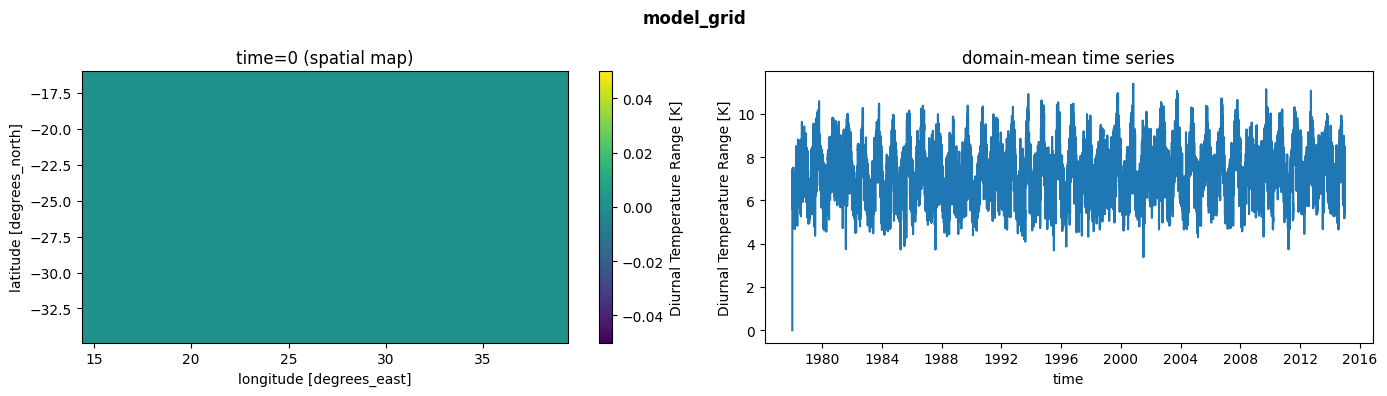

In [6]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice)
model_grid = inspect(model_grid, "model_grid")


  obs_coarse_stage1
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 20, 'lon': 20}
  NaN:   0.0000 (0.00%)


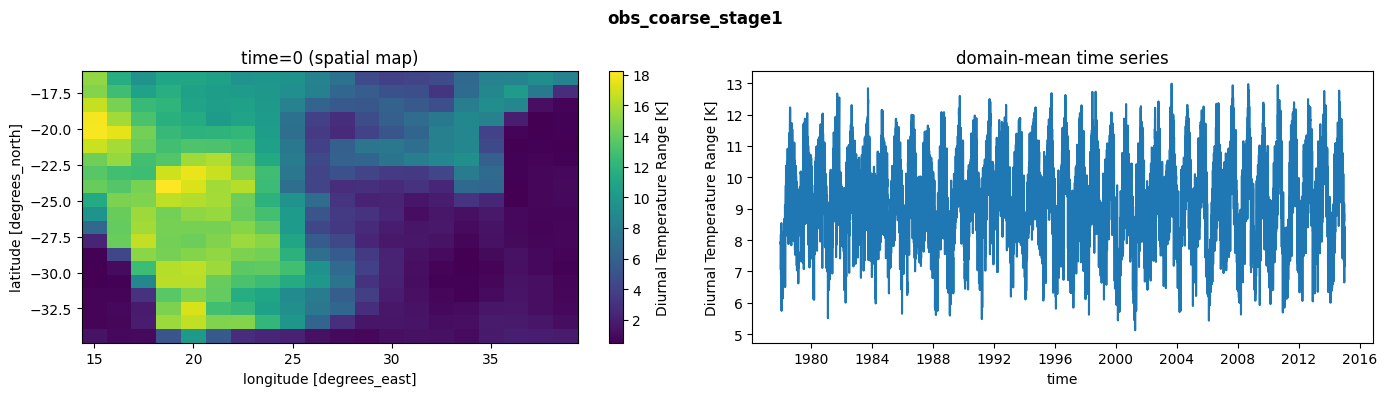

In [7]:
# ── obs_coarse: ERA5 obs regridded to the GCM coarse grid ─────────────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
)
obs_coarse_stage1 = inspect(obs_coarse_stage1, "obs_coarse_stage1")

In [8]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...
  2026-07-02T18:26:48.661739Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-07-02T18:26:49.109732Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat-35.0to-16.0_lon15.0to39.0.icechunk
CPU times: user 6min 39s, sys: 2min 34s, total: 9min 14s
Wall time: 4min 15s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


  2026-07-02T18:31:04.660829Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-07-02T18:31:04.661365Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196


  obs_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 20, 'lon': 20}
  NaN:   0.0000 (0.00%)


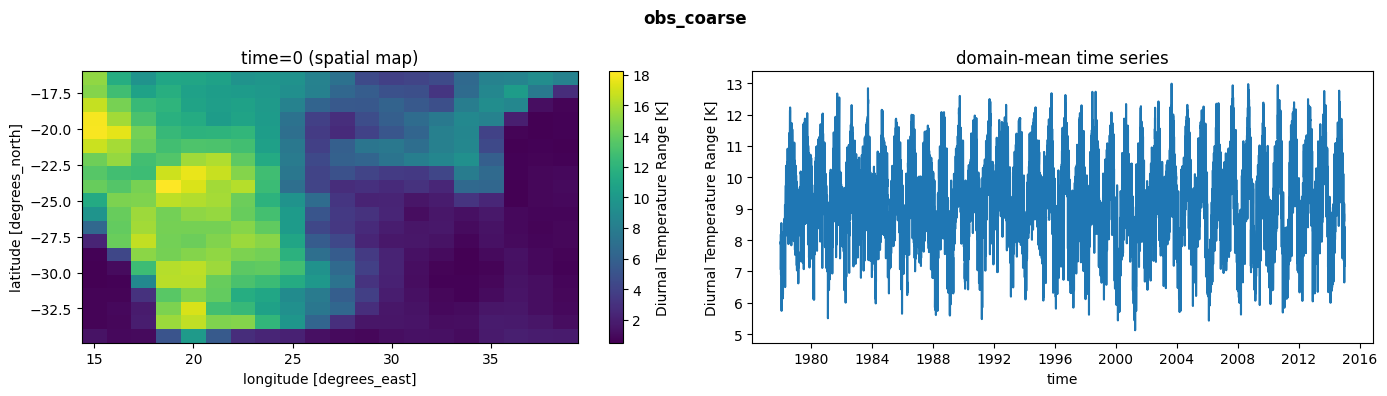


  obs_fine_s2
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 77, 'lon': 97}
  NaN:   0.0000 (0.00%)


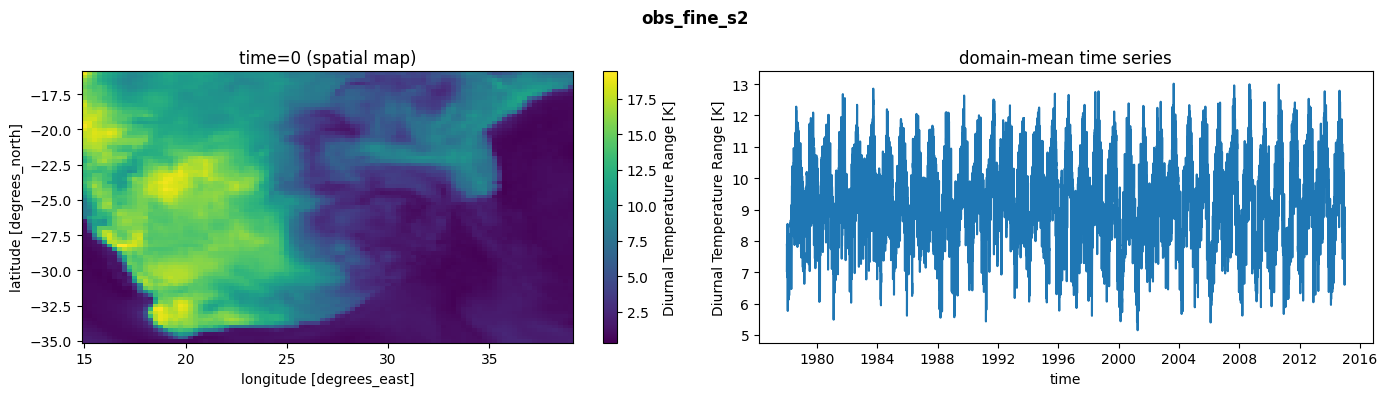


  model_hist
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 20, 'lon': 20}
  NaN:   0.0000 (0.00%)


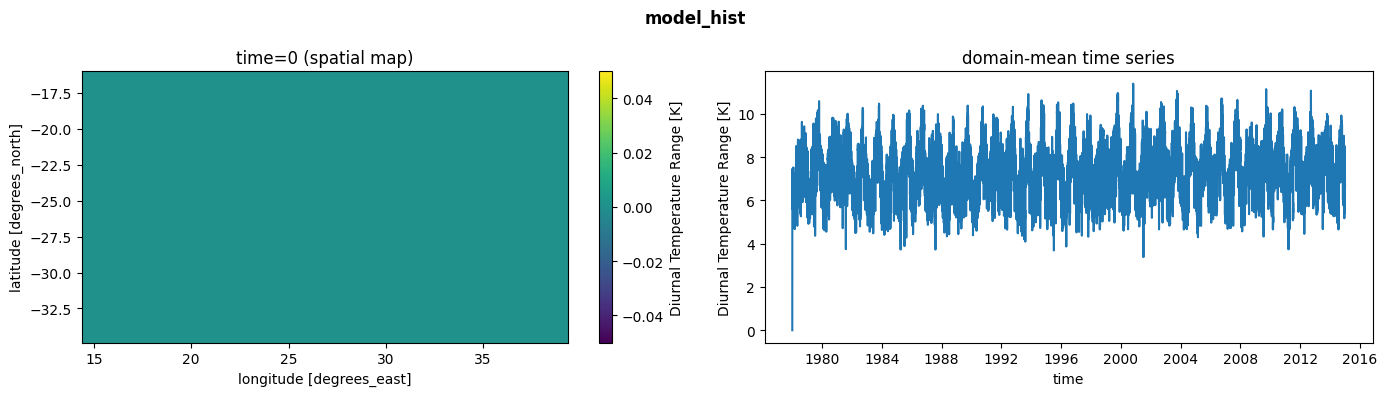

CPU times: user 3min 59s, sys: 1min 33s, total: 5min 32s
Wall time: 2min 17s


In [9]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
obs_coarse = inspect(obs_coarse, "obs_coarse")
obs_fine_s2 = inspect(obs_fine_s2, "obs_fine_s2")
model_hist = inspect(model_hist, "model_hist")


  debiased_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 20, 'lon': 20}
  NaN:   0.0000 (0.00%)


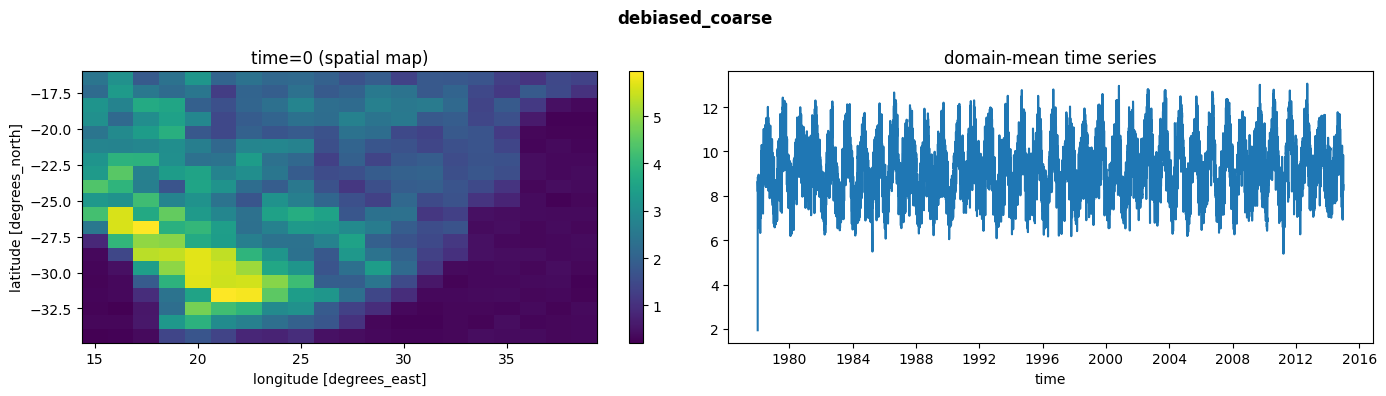

CPU times: user 308 ms, sys: 529 ms, total: 838 ms
Wall time: 5.17 s


In [10]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)
debiased_coarse = inspect(debiased_coarse, "debiased_coarse")

# Check mean bias of the dtr from the coarse obs - what biases remain even after bias-correction

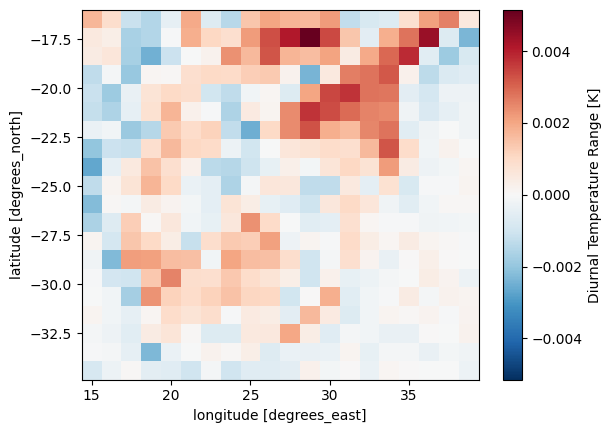

In [11]:
(debiased_coarse.mean(dim='time')-obs_coarse.mean(dim='time')).plot()

### Spatial disaggregation sub-steps (Stage 2)

The single `_apply_spatial_downscaling()` call is expanded into five named
intermediates (Cells A–E) plus a consistency check (Cell F), so each step
can be inspected independently. These mirror the internals of
`downscale_from_coarse()` exactly.

> **Cell A** and **Cell B** compute the obs climatology, which is
> scenario-independent. The arrays will be reused in Stage 3 (starting from
> Cell C) so those cells do not need to rerun them.



  obs_fine_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 77, 'lon': 97}
  NaN:   0.0000 (0.00%)


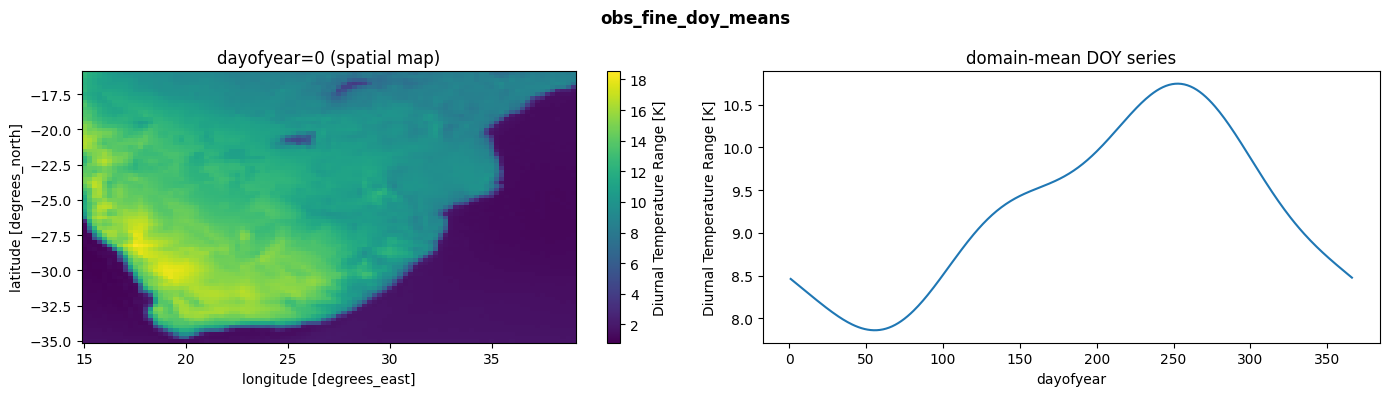

CPU times: user 874 ms, sys: 7.65 ms, total: 882 ms
Wall time: 642 ms


In [12]:
%%time
# ── Cell A: fine-grid day-of-year climatology ──────────────────────────────────
# Uses the downscaling_clim_method from config (typically "fft" for most vars).
obs_fine_doy_means = calculate_doy_means(obs_fine_s2, clim_method=config.downscaling_clim_method, allow_negative_values=False)
obs_fine_doy_means = inspect(obs_fine_doy_means, "obs_fine_doy_means")

## Inspect the difference if you were to create `obs_fine_doy_means` using the two different options of `clim_method`: simple or fft.

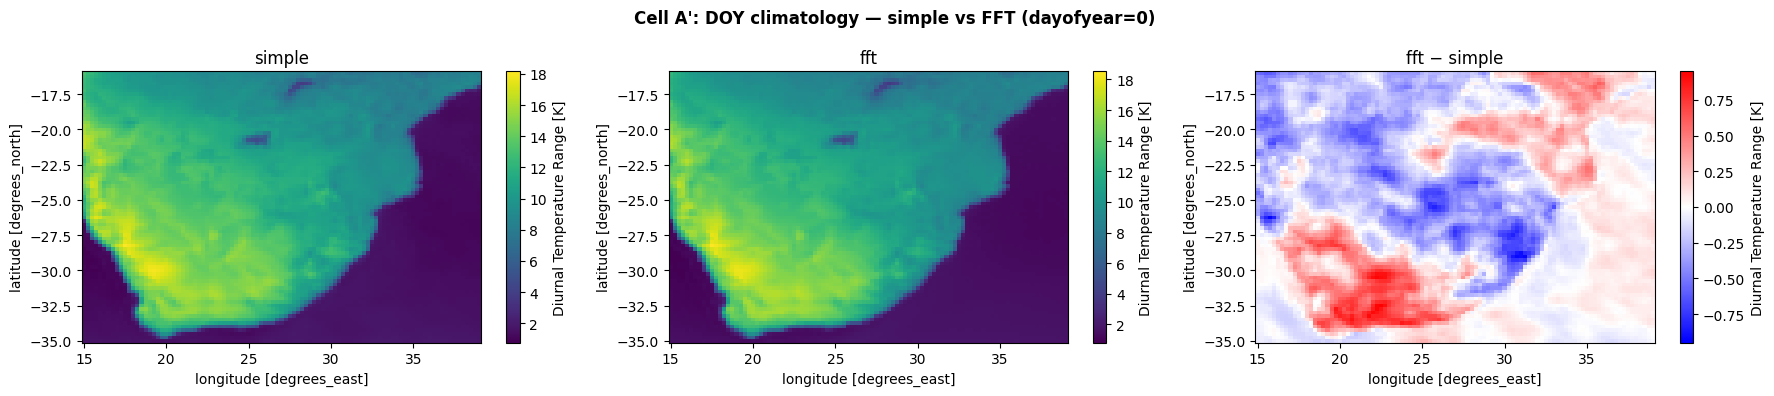

CPU times: user 983 ms, sys: 0 ns, total: 983 ms
Wall time: 522 ms


In [13]:
%%time
# ── Cell A': FFT vs simple climatology comparison ─────────────────────────────
# Three-panel map: simple | fft | diff (bwr, center=0) for dayofyear=0.
# Reveals FFT-smoothing artifacts found in prior QA notebooks.
obs_fine_doy_means_simple = calculate_doy_means(obs_fine_s2, clim_method="simple", allow_negative_values=False)
obs_fine_doy_means_fft = calculate_doy_means(obs_fine_s2, clim_method="fft", allow_negative_values=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Cell A': DOY climatology — simple vs FFT (dayofyear=0)", fontweight="bold")
kw = dict(add_colorbar=True)
obs_fine_doy_means_simple.isel(dayofyear=0).plot(ax=axes[0], **kw)
axes[0].set_title("simple")
obs_fine_doy_means_fft.isel(dayofyear=0).plot(ax=axes[1], **kw)
axes[1].set_title("fft")
diff = (obs_fine_doy_means_fft - obs_fine_doy_means_simple).isel(dayofyear=0)
diff.plot(ax=axes[2], cmap="bwr", center=0, **kw)
axes[2].set_title("fft − simple")
plt.tight_layout()
plt.show()

## Coarsen the finescale doy means. This creates the a coarse doy dataset that is consistent with the smoothed finescale DOY means.


  obs_coarse_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 20, 'lon': 20}
  NaN:   0.0000 (0.00%)


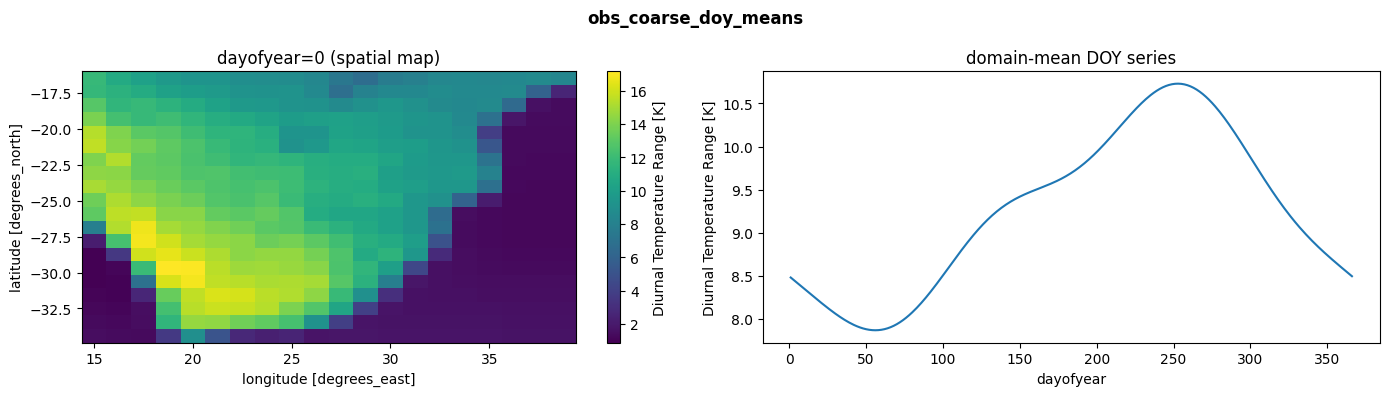

In [14]:
# ── Cell B: coarsen DOY climatology to GCM grid ───────────────────────────────
obs_coarse_doy_means = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine_doy_means, da_coarse_grid=obs_coarse
)
obs_coarse_doy_means = inspect(obs_coarse_doy_means, "obs_coarse_doy_means")


  residuals_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 20, 'lon': 20}
  NaN:   0.0000 (0.00%)


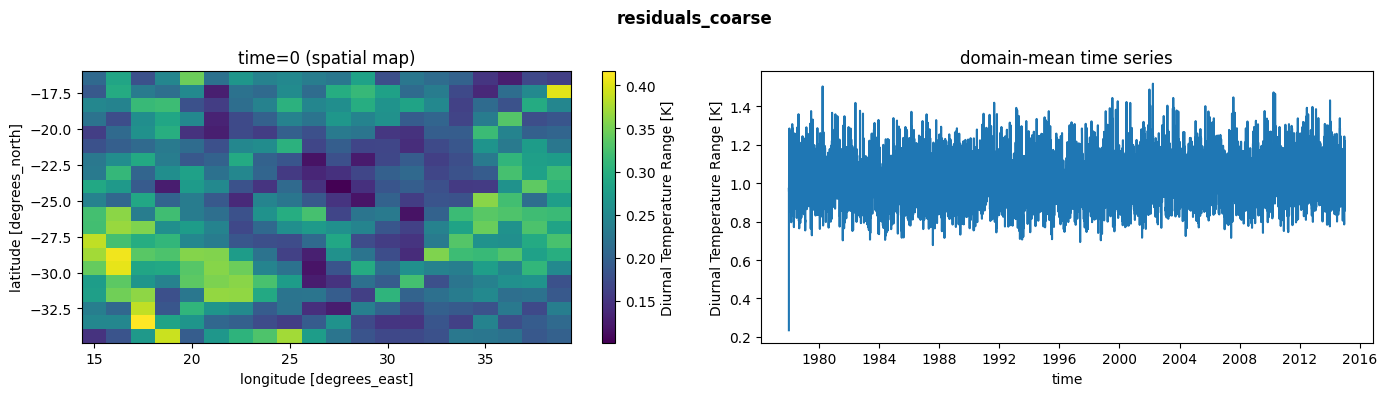

In [15]:
high_clip = 10000
clip100 = 100
clip10 = 10
# ── Cell C: coarse spatial residuals (debiased − coarse climatology) ──────────
# residuals_coarse is how different that debiased GCM pixel on that day is from the typical 
# (coarse) obs on that same day of year. for instance, for temperature, it says
# "the debiased GCM here for this day is 3 degrees warmer than the mean obs here" or "the debiased GCM
# here for this day is 10x wetter than the mean". it can happen, particularly for precipitation,
# if there were essentially no big storms in the obs for that pixel, and in the GCM it happens to get a storm,
# that the residual can be very high.
if config.downscaling_method == "additive":
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.downscaling_method == "multiplicative":
    zero_clim = obs_coarse_doy_means == 0
    obs_coarse_doy_means_safe = obs_coarse_doy_means.where(~zero_clim)  # zeros -> NaN


    residuals_coarse = debiased_coarse.groupby("time.dayofyear") / obs_coarse_doy_means_safe

    # Force ratio to 0 exactly where the coarse climatology was zero.
    # Broadcast the per-DOY zero mask back onto the time axis.
    zero_clim_on_time = zero_clim.sel(dayofyear=debiased_coarse["time"].dt.dayofyear)
    residuals_coarse = residuals_coarse.where(~zero_clim_on_time, 0.0).clip(max=high_clip)
    residuals_coarse_clipped10 = residuals_coarse.clip(max=clip10)
    residuals_coarse_clipped100 = residuals_coarse.clip(max=clip100)
residuals_coarse = inspect(residuals_coarse, "residuals_coarse")

## Inspect the largest residual along the time dimension

DTR doesn't have the same residual issues as other variables.

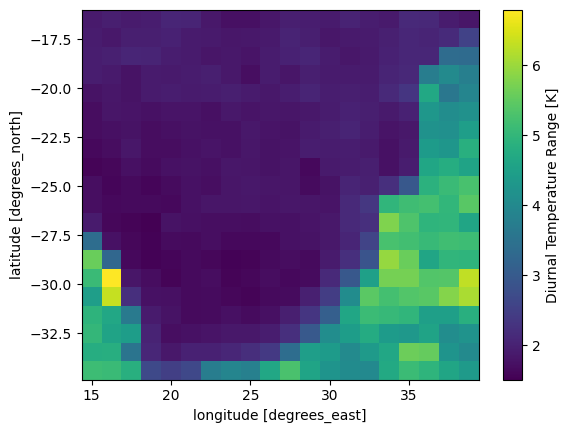

In [17]:
residuals_coarse.max(dim='time').plot()


  residuals_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 77, 'lon': 97}
  NaN:   0.0746 (7.46%)


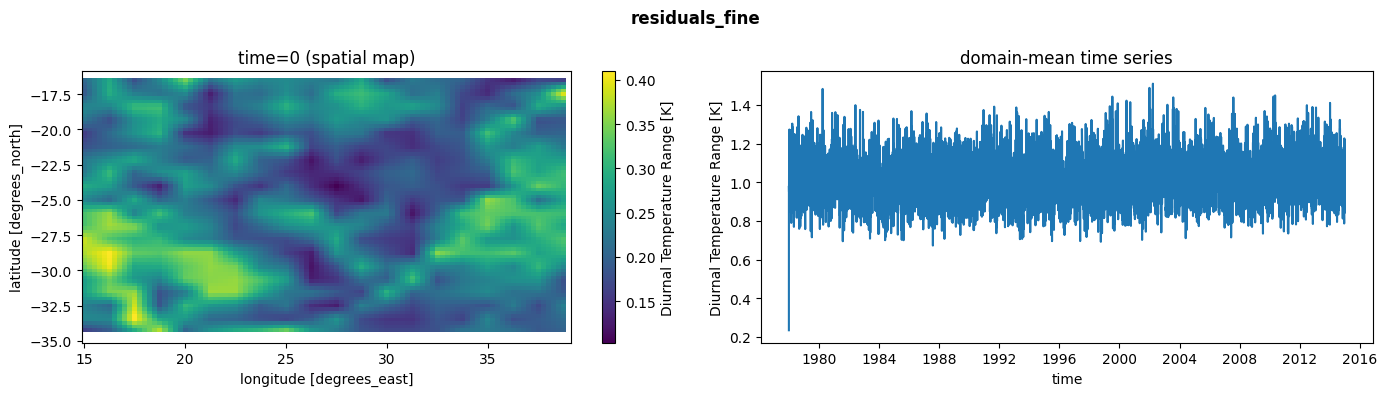

In [18]:
# ── Cell D: interpolate residuals to fine grid ────────────────────────────────
residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse, da_fine_grid=obs_fine_s2
)
residuals_fine = inspect(residuals_fine, "residuals_fine")


  downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 77, 'lon': 97}
  NaN:   0.0746 (7.46%)


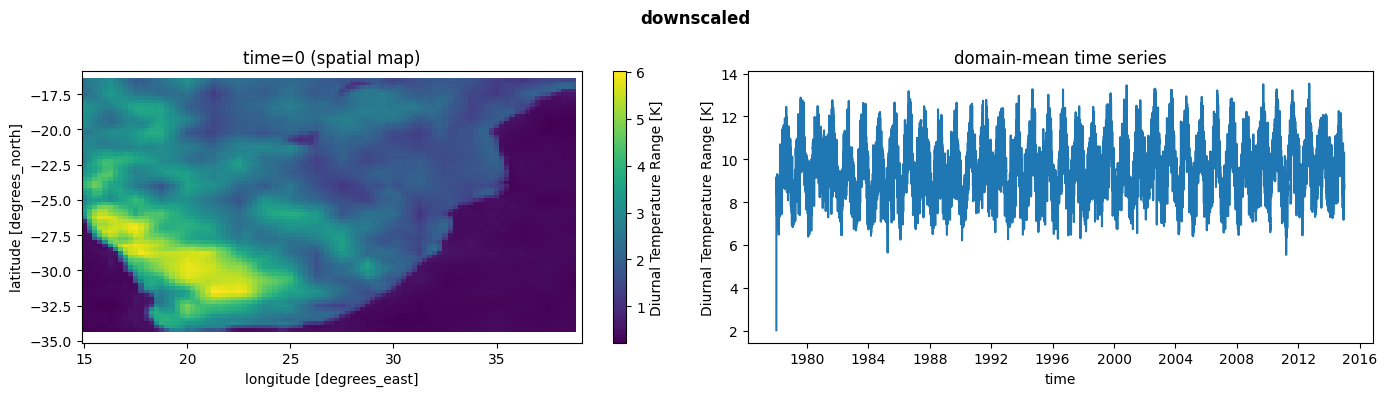

In [19]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.downscaling_method == "additive":
    downscaled = residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.downscaling_method == "multiplicative":
    downscaled = residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
downscaled = inspect(downscaled, "downscaled")

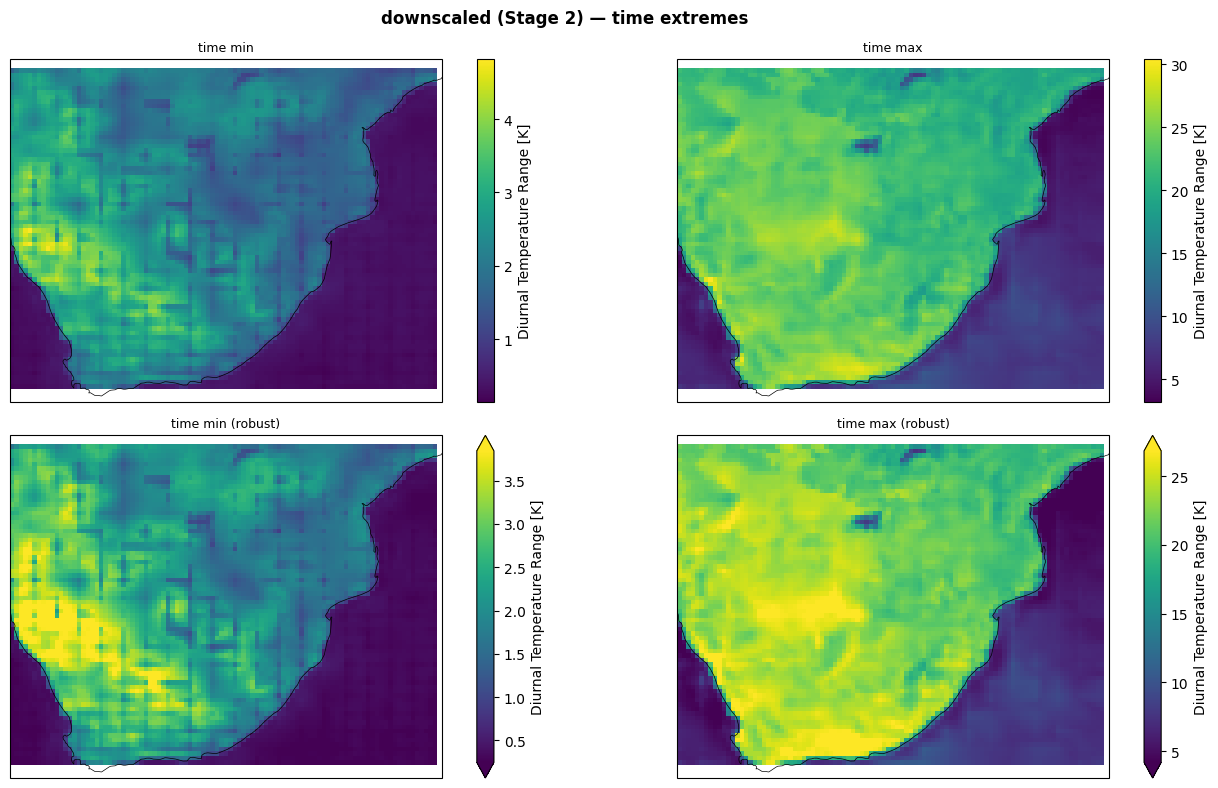


── ERA5-relative exceedance: downscaled (Stage 2) (annual) ──
  ✗ days > ERA5 max: 561/7469 pixels flagged (7.5%)


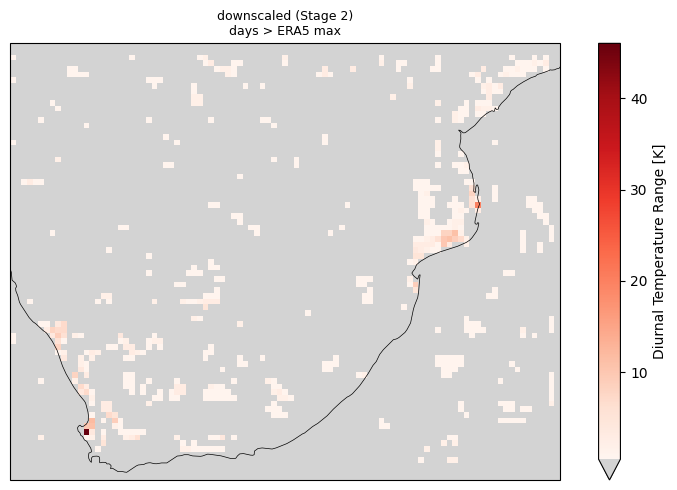

  ✗ days < ERA5 min: 58/7469 pixels flagged (0.8%)


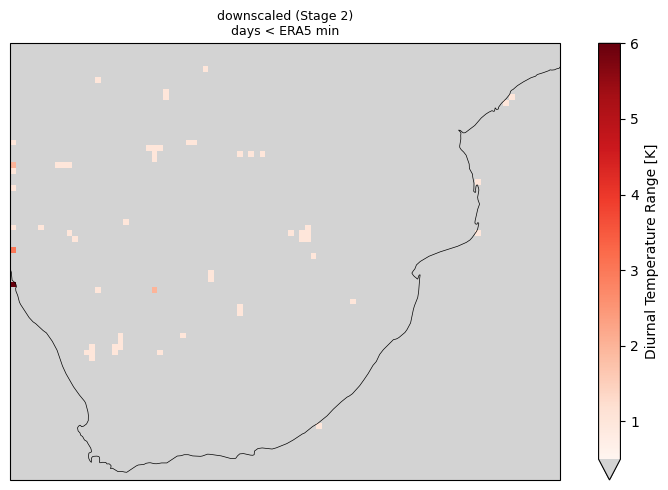

In [20]:
# ── ERA5 exceedance check: downscaled (Stage 2) ───────────────────────────────
# plot_time_extremes: 2×2 grid catches both sign errors (negative pr)
# and extreme outliers that a mean or single-timestep map would hide.
plot_time_extremes(downscaled, "downscaled (Stage 2)")

# Annual check first (fast); switch to period="monthly" to localise
# seasonally-specific exceedances (e.g. summer precipitation extremes).
check_era5_exceedances(downscaled, obs_fine_s2, "downscaled (Stage 2)")
# check_era5_exceedances(downscaled, obs_fine_s2, "downscaled (Stage 2)", period="monthly")

In [16]:
%%time
# ── Cell F: consistency check vs production downscale_from_coarse() ───────────
# Fails loudly if step-by-step result diverges from the production function.
ref = downscale_from_coarse(
    da=debiased_coarse,
    obs_coarse=obs_coarse,
    obs_fine=obs_fine_s2,
    method=config.downscaling_method,
    clim_method=config.downscaling_clim_method,
    allow_negative_values=False,
    max_residual=100
).compute()

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xf0d69b703750>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xf0d6b2825fd0>, 24245.098381577)])']
connector: <aiohttp.connector.TCPConnector object at 0xf0d6b008a350>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xf0d69b701e50>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xf0d6b2826190>, 24245.100568012)])']
connector: <aiohttp.connector.TCPConnector object at 0xf0d69b701a90>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xf0d6b3273250>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xf0d6b28260b0>, 24245.102936034)])']
connector: <aiohttp.connector.TCPConnector object at 0xf0d6b3272e90>


CPU times: user 984 ms, sys: 37.7 ms, total: 1.02 s
Wall time: 787 ms


In [ ]:
# ── Optional: write historical to debug cache for Stage 3 ─────────────────────
# Only needed if you plan to run Stage 3 cells below.  Uncomment and run.
# print("Writing fit_historical to debug cache ...")
# hist_path = pipeline.fit_historical(force=True)
# print(f"  → {hist_path}")


### tasmin special path

If `VARIABLE == "tasmin"`, `fit_historical_tasmin` / `transform_scenario_tasmin`
compute `tasmin = debiased_tasmax − debiased_dtr` instead of debiasing tasmin
directly. To debug that path:

1. Run `fit_historical(force=True)` for **dtr** and **tasmax** with
   `save_intermediate=True` (so the debiased intermediates are written to the
   debug cache).
2. Then load them:
   ```python
   if config.variable == "tasmin":
       debiased_dtr_loc = pipeline.cache.debiased_historical_loc(
           pipeline._hist_member, variable="dtr"
       )
       debiased_tasmax_loc = pipeline.cache.debiased_historical_loc(
           pipeline._hist_member, variable="tasmax"
       )
       debiased_dtr = pipeline._open_from_icechunk(debiased_dtr_loc)["dtr"]
       debiased_tasmax = pipeline._open_from_icechunk(debiased_tasmax_loc)["tasmax"]
       debiased_tasmin = debiased_tasmax - debiased_dtr
       debiased_tasmin = inspect(debiased_tasmin, "debiased_tasmin_from_dtr")
       # then run _apply_spatial_downscaling and inspect as above
   ```


## Stage 3 — `transform_scenario`

Cells below run only when `SCENARIO` is set in the config cell. Run
`pipeline.fit_historical(force=True)` (the optional cell at the end of
Stage 2) before executing these cells, so the historical artifact exists in
the debug cache and `_load_scenario_data()` can validate its dependency.


In [ ]:
if config.scenario is None:
    raise RuntimeError(
        "SCENARIO is None. Set SCENARIO in the config cell and re-run "
        "from the top before executing Stage 3 cells."
    )

In [ ]:
%%time
# ── _load_scenario_data ────────────────────────────────────────────────────────
(
    obs_coarse_s3,
    obs_fine_s3,
    model_hist_s3,
    model_scenario,
    ssp_timeseries,
) = pipeline._load_scenario_data()

obs_coarse_s3 = inspect(obs_coarse_s3, "obs_coarse_s3")
obs_fine_s3 = inspect(obs_fine_s3, "obs_fine_s3")
model_hist_s3 = inspect(model_hist_s3, "model_hist_s3")
model_scenario = inspect(model_scenario, "model_scenario")
if ssp_timeseries is not None:
    ssp_timeseries = inspect(ssp_timeseries, "ssp_timeseries")

In [ ]:
# ── _detrend_scenario ──────────────────────────────────────────────────────────
scenario_detrended, scenario_trend = pipeline._detrend_scenario(
    model_hist_s3, model_scenario, ssp_timeseries
)
scenario_detrended = inspect(scenario_detrended, "scenario_detrended")
if scenario_trend is not None:
    scenario_trend = inspect(scenario_trend, "scenario_trend")

# Visual comparison: detrended vs raw scenario to confirm detrending direction.
fig, ax = plt.subplots(figsize=(12, 4))
model_scenario.mean(["lat", "lon"]).plot(ax=ax, label="model_scenario (raw)")
scenario_detrended.mean(["lat", "lon"]).plot(ax=ax, label="scenario_detrended")
ax.legend()
ax.set_title("Domain-mean: raw scenario vs detrended")
plt.tight_layout()
plt.show()

In [ ]:
%%time
# ── _apply_bias_correction_scenario ───────────────────────────────────────────
scenario_debiased = pipeline._apply_bias_correction_scenario(
    obs_coarse_s3, model_hist_s3, scenario_detrended
)
scenario_debiased = inspect(scenario_debiased, "scenario_debiased")

In [ ]:
# ── retrend (only if scenario_trend exists) ───────────────────────────────────
if scenario_trend is not None:
    scenario_debiased = retrend(scenario_debiased, scenario_trend, config.detrend_method)
    scenario_debiased = inspect(scenario_debiased, "scenario_debiased_retrended")
else:
    print("No trend to reapply (detrend_data=False for this variable).")

### Scenario spatial disaggregation sub-steps

Cells A and B (obs climatology) were already computed in Stage 2 as
`obs_fine_doy_means` and `obs_coarse_doy_means`. Reuse them here; start from
Cell C.


In [ ]:
# ── Cell C (scenario): coarse spatial residuals ───────────────────────────────
if config.downscaling_method == "additive":
    scenario_residuals_coarse = scenario_debiased.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.downscaling_method == "multiplicative":
    scenario_residuals_coarse = scenario_debiased.groupby("time.dayofyear") / obs_coarse_doy_means
scenario_residuals_coarse = inspect(scenario_residuals_coarse, "scenario_residuals_coarse")

In [ ]:
# ── Cell D (scenario): interpolate residuals to fine grid ─────────────────────
# NaN introduced here (interpolation step) vs Cell E (climatology add-back)
# becomes immediately visible as a jump in nan_fraction.
scenario_residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=scenario_residuals_coarse, da_fine_grid=obs_fine_s3
)
scenario_residuals_fine = inspect(scenario_residuals_fine, "scenario_residuals_fine")

In [ ]:
# ── Cell E (scenario): reapply fine-grid DOY climatology ──────────────────────
if config.downscaling_method == "additive":
    scenario_downscaled = scenario_residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.downscaling_method == "multiplicative":
    scenario_downscaled = scenario_residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
scenario_downscaled = inspect(scenario_downscaled, "scenario_downscaled")

In [ ]:
# ── ERA5 exceedance check: scenario_downscaled (Stage 3) ─────────────────────
# obs_fine_s3 is the ERA5 reference — already in memory from _load_scenario_data().
# This cell is the primary regression detector for the all-NaN finding
# documented in pipeline-intermediate-checks-issue-357.ipynb.
plot_time_extremes(scenario_downscaled, "scenario_downscaled (Stage 3)")

check_era5_exceedances(scenario_downscaled, obs_fine_s3, "scenario_downscaled (Stage 3)")
# check_era5_exceedances(scenario_downscaled, obs_fine_s3, "scenario_downscaled (Stage 3)", period="monthly")

In [ ]:
%%time
# ── Cell F (scenario): consistency check vs production downscale_from_coarse() ─
ref_scenario = downscale_from_coarse(
    da=scenario_debiased,
    obs_coarse=obs_coarse_s3,
    obs_fine=obs_fine_s3,
    method=config.downscaling_method,
    clim_method=config.downscaling_clim_method,
).compute()

match_s3 = np.allclose(scenario_downscaled.values, ref_scenario.values, equal_nan=True)
print(f"Consistency check (Cell F, scenario): {'PASS ✓' if match_s3 else 'FAIL ✗'}")
assert match_s3, (
    "Step-by-step scenario result diverges from downscale_from_coarse(). "
    "Check residual formulation or interpolation order."
)

In [ ]:
# ── Ocean mask (only if apply_ocean_mask is enabled) ─────────────────────────
if options.apply_ocean_mask:
    mask = pipeline._build_ocean_mask(scenario_downscaled)
    land_frac = float(mask.mean())
    print(f"Ocean mask land coverage: {land_frac:.2%}")
    mask.plot(figsize=(8, 4))
    plt.title("Ocean mask (True = land)")
    plt.show()

    scenario_downscaled_masked = scenario_downscaled.where(mask)
    scenario_downscaled_masked = inspect(scenario_downscaled_masked, "scenario_downscaled_masked")
else:
    print("apply_ocean_mask=False — skipping ocean mask step.")

## Cross-stage evolution plots

Re-run this section at any point — it iterates over whatever is in `STEPS`
so far. Four complementary views:

1. **Faceted spatial maps** — shared and per-panel color scales
2. **Overlaid domain-mean time series** — reveals trend/level shifts
3. **Overlaid value distributions** — shows how bias-correction reshapes tails
4. **NaN-fraction bar chart** — one glance to see where NaNs first appear


In [ ]:
# ── 1. Faceted spatial maps ───────────────────────────────────────────────────
time_steps = {k: v for k, v in STEPS.items() if "time" in v.dims}
if time_steps:
    n = len(time_steps)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    fw, fh = 5.5 * ncols, 5 * nrows

    # ── shared color scale ──────────────────────────────────────────────────
    ref = list(time_steps.values())[0]
    vmin = float(ref.quantile(0.02))
    vmax = float(ref.quantile(0.98))

    fig, axes = plt.subplots(nrows, ncols, figsize=(fw, fh), squeeze=False, layout="constrained")
    mappable = None
    for ax, (step, da) in zip(axes.flat, time_steps.items()):
        p = da.isel(time=0).plot(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False)
        ax.set_title(_step_title(step), fontsize=8)
        if mappable is None:
            mappable = p  # real QuadMesh — constrained_layout places colorbar correctly
    for ax in list(axes.flat)[n:]:
        ax.set_visible(False)
    fig.colorbar(mappable, ax=axes, shrink=0.6, label=config.variable)
    fig.suptitle("Faceted spatial maps — shared color scale (time=0)", fontweight="bold")
    plt.show()

    # ── per-panel robust scale ────────────────────────────────────────────────
    # Each panel has its own independent color scale — good for spotting spatial
    # structure that gets washed out under a shared scale. constrained_layout
    # sizes the per-panel colorbars without squishing the axes.
    fig, axes = plt.subplots(nrows, ncols, figsize=(fw, fh), squeeze=False, layout="constrained")
    for ax, (step, da) in zip(axes.flat, time_steps.items()):
        da.isel(time=0).plot(
            ax=ax, robust=True, add_colorbar=True, cbar_kwargs={"shrink": 0.8, "pad": 0.02}
        )
        ax.set_title(_step_title(step), fontsize=8)
    for ax in list(axes.flat)[n:]:
        ax.set_visible(False)
    fig.suptitle(
        "Faceted spatial maps — per-panel robust scale (time=0)\n"
        "color scale is independent per panel",
        fontweight="bold",
        fontsize=10,
    )
    plt.show()
else:
    print("No time-dim steps in STEPS yet.")

In [ ]:
# ── 2. Overlaid domain-mean time series ──────────────────────────────────────
# Physical-unit steps (obs, debiased, downscaled …) go on one plot; anomaly
# and trend steps (centred near 0) go on another — mixing squashes one group.
time_steps = {k: v for k, v in STEPS.items() if "time" in v.dims}
if time_steps:

    def _is_anomaly(k):
        return "residual" in k or k.endswith("_trend")

    physical = {k: v for k, v in time_steps.items() if not _is_anomaly(k)}
    anomalies = {k: v for k, v in time_steps.items() if _is_anomaly(k)}

    for group, title in [
        (physical, "Domain-mean time series — physical-unit steps"),
        (anomalies, "Domain-mean time series — residual / trend steps"),
    ]:
        if not group:
            continue
        fig, ax = plt.subplots(figsize=(14, 5))
        for step, da in group.items():
            da.mean(["lat", "lon"]).plot(ax=ax, label=step, linewidth=1)
        ax.legend(fontsize=8, ncol=2)
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

In [ ]:
# ── 3. Overlaid value distributions ──────────────────────────────────────────
time_steps = {k: v for k, v in STEPS.items() if "time" in v.dims}
if time_steps:

    def _is_anomaly(k):
        return "residual" in k or k.endswith("_trend")

    physical = {k: v for k, v in time_steps.items() if not _is_anomaly(k)}
    anomalies = {k: v for k, v in time_steps.items() if _is_anomaly(k)}

    for group, title in [
        (physical, "Value distributions — physical-unit steps"),
        (anomalies, "Value distributions — residual / trend steps"),
    ]:
        if not group:
            continue
        fig, ax = plt.subplots(figsize=(12, 5))
        for step, da in group.items():
            vals = da.values.ravel()
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                ax.hist(vals, bins=60, histtype="step", density=True, label=step, linewidth=1.5)
        ax.legend(fontsize=8, ncol=2)
        ax.set_title(title)
        ax.set_xlabel(config.variable)
        ax.set_ylabel("density")
        plt.tight_layout()
        plt.show()

In [ ]:
# ── 4. NaN-fraction by step ───────────────────────────────────────────────────
if STEP_NAN_FRACTIONS:
    labels = list(STEP_NAN_FRACTIONS.keys())
    fracs = [STEP_NAN_FRACTIONS[k] for k in labels]
    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.8), 4))
    colors = ["#d62728" if f > 0 else "#2ca02c" for f in fracs]
    ax.bar(labels, fracs, color=colors)
    ax.set_ylabel("NaN fraction")
    ax.set_title("NaN fraction by pipeline step")
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("No QA results yet — run inspect() on at least one time-dim step first.")